# pyGAlib example: Generation weighted (random) graphs and weighted surrogates
Authors: **Gorka Zamora-López, Ph.D.** and **Matthieu Gilson, Ph.D.**

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>


<img src="Images/logo_CONECT.png" align="right" width="150" alt="logo CONECT">
<img src="Images/logo_AMU.png" align="right" width="150" alt="logo AMU">


<br>
<br>

---------------------

This notebook illustrate the options in *pyGAlib* to generate weighted graphs and weighted surrogates. In particular we will show how to:

1. add random weights to existing graphs and digraphs,
2. generate (random) weighted (di)graphs, and
3. create surrogate weighted graphs from a given network.

Functions to create both binary and weighted graphs can be found in module *models.py*. As usual, type `help(galib.models)` or `models?` in an interactive Python session to get a list of all network generation functions and, specific instructions for each generating function as `help(galib.FunctionName)` or `galib.FunctionName?`.


## Import dependencies

The Notebook requires a __*Python*__ (>=3.6) installation together with __*NumPy*__ (>1.6) and __*pyGAlib*__ (>=2.1), and __*Matplotlib*__ for the visualizations. Please make sure these packages are installed in the same environment in which this notebook is running.


In [1]:
# 1) Python standard library imports

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local libraries
import galib


## 1. Seeding random weights to existing graphs and digraphs
To begin with, let's generate a small graph (e.g., a star graph) and add random weights to its links, drawn from random number distribution of choice. For that, we will use function `galib.SeedRandomWeights()`. The function accepts: 

1. Two mandatory positional parameters:
    - `adjmatrix` corresponding the (di)graph to which weights will be added, and
    - `w_dist` the random number generator function, e.g., from *NumPy* or the *SciPy* packages.
2. Various optional parameters. We will see them later.
3. Keyword arguments (`**arg_w_distr`) usually related to the random number generator `w_dist`. 

> NOTE: In *pyGAlib* functions to generate binary (di)graphs return 2D *ndarrays* of `np.uint8` dtype. Adding random weights, or generating a new (randomly) weigthed graph returns them in `np.float64` dtype.

### 1.1. – Undirected graphs

Are the networks directed?  net: False  wnet1: False  wnet2: False
Are the weights symmetric?  net: True  wnet1: True  wnet2: True


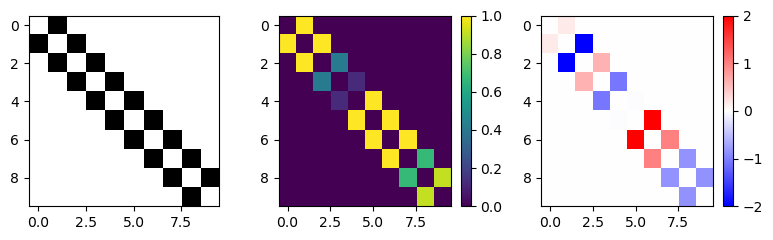

In [25]:
# Create a small graph
N = 10
#net = galib.StarGraph(N)
net = galib.PathGraph(N)

# Create two weigthed versions, seeding weights from a uniform and a normal distributions.
# Parameters of the random number generator are passed as keyword arguments. 
# For the uniform distribution (between 0 and 1) these will be `low = 0` and `high = 1`
wnet1 = galib.SeedRandomWeights(net, np.random.uniform,  low=0, high=2)
# For the normal distribution these will be `loc=0` and `scale=2`.
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  loc=0, scale=2)

# Print some feedback ...
print( f"Are the networks directed?  net: {galib.is_directed(net)}  wnet1: {galib.is_directed(wnet1)}  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are the weights symmetric?  net: {galib.is_symmetric(net)}  wnet1: {galib.is_symmetric(wnet1)}  wnet2: {galib.is_symmetric(wnet2)}" )


# Visualize the generated matrices
plt.figure(figsize=(8,2.5))
plt.subplot(1,3,1)
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wnet1, aspect='auto')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(wnet2, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As seen, symmetric weights were seeded such that $w_{ij} = w_{ji}$. This is because `SeedRandomWeights()` identifies whether the input adjacency matrix represents a directed or and undirected graph and behaves accordingly.

- If the input `adjmatrix` is undirected, then it will seed weights symmetrically.
- Instead, if the input `adjmatrix` is a directed graph, it will seed weigths non-symmetrically.

However, this behaviour can be overwritten using optional parameter `sym_w`. By default `sym_w = None`, which makes the function to first check the directedness of the input matrix `adjmatrix` and behave accordingly. But, setting `sym_w = False` the weights will be randomly assigned ignoring whether the input matrix is an undirected graph or not, and returning an asymmetric connectivity matrix such that $w_{ij} \neq w_{ji}$, in general.

Let's now seed the weights to `net` using `sym_w = False`.

Are the networks directed?  net: False  wnet1: False  wnet2: False
Are the weights symmetric?  net: True  wnet1: False  wnet2: False


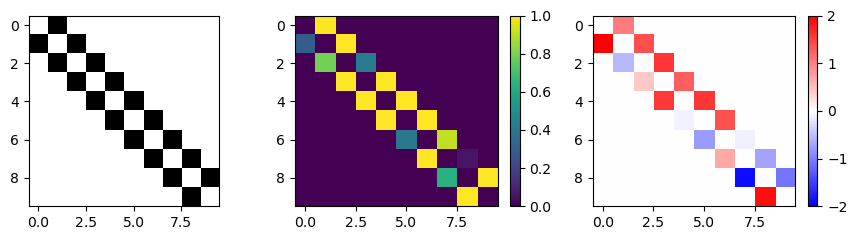

In [26]:
# Set optional parameter sym_w = False
wnet1 = galib.SeedRandomWeights(net, np.random.uniform, sym_w=False,  low=0, high=2)
wnet2 = galib.SeedRandomWeights(net, np.random.normal,  sym_w=False,  loc=0, scale=2)

# Print some feedback ...
print( f"Are the networks directed?  net: {galib.is_directed(net)}  wnet1: {galib.is_directed(wnet1)}  wnet2: {galib.is_directed(wnet2)}" )
print( f"Are the weights symmetric?  net: {galib.is_symmetric(net)}  wnet1: {galib.is_symmetric(wnet1)}  wnet2: {galib.is_symmetric(wnet2)}" )


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.imshow(net, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wnet1, aspect='auto')
plt.clim(0,1)
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(wnet2, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As expected, the graphs are still undirected but the weights are not symmetric.

On the other hand, we can also overwrite the default option to `sym_w = True`. In this case, 

- if the graph is **undirected** we obtain the default behaviour in which that weights are symmetrically planted. But,
- if the graph is **directed**, then the function distinguishes between reciprocal and non-reciprocal links. It will assign symmetric weights to reciprocal links ($w_{ij} = w_{ji}$ if $A_{ij} = A_{ji} = 1$) while purely directed links receive their own independent weight.


### 1.2. – Directed graphs

By default, if the input `adjmatrix` corresponds to a directed graph, then weights will randomly assigned, without any concerns for symmetry.

Are the networks directed?  dirnet: True   wdirnet: True
Are the weights symmetric?  dirnet: False  wdirnet: False


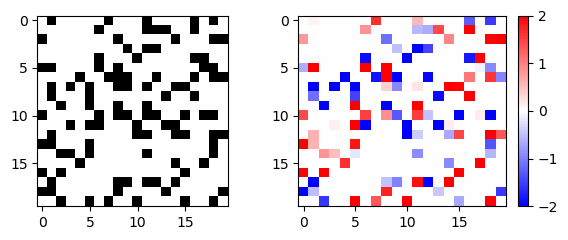

In [37]:
N = 20
linkprob = 0.3

# Create the binary random graph 
dirnet = galib.ErdosRenyiGraph(N,linkprob, directed=True)
# Assign random weights, calling sym_w=True in the directed graph
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal, loc=0,scale=2)

# Print some feedback ...
print( f"Are the networks directed?  dirnet: {galib.is_directed(dirnet)}   \
wdirnet: {galib.is_directed(wdirnet)}" )
print( f"Are the weights symmetric?  dirnet: {galib.is_symmetric(dirnet)}  \
wdirnet: {galib.is_symmetric(wdirnet)}" )


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wdirnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


But, if the `sym_w` parameter is set to `True`, then we will see the following:

Are the networks directed?  dirnet: True   wdirnet: True
Are the weights symmetric?  dirnet: False  wdirnet: False


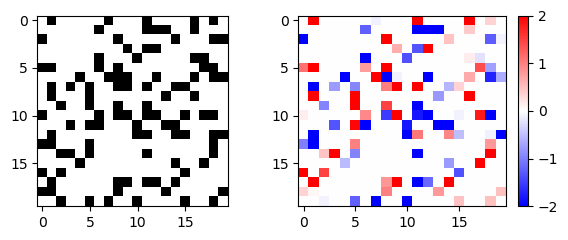

In [38]:
# Assign random weights, calling sym_w=True in the directed graph
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal,  sym_w=True,  loc=0,scale=2)

# Print some feedback ...
print( f"Are the networks directed?  dirnet: {galib.is_directed(dirnet)}   \
wdirnet: {galib.is_directed(wdirnet)}" )
print( f"Are the weights symmetric?  dirnet: {galib.is_symmetric(dirnet)}  \
wdirnet: {galib.is_symmetric(wdirnet)}" )


# Visualize the generated matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,3,2)
plt.imshow(wdirnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


It might be difficult to see by looking at the connectivity matrices which links are reciprocal and symmetric, and which are purely directed. To better identify them, we can identify the repriprocal and the directed components, and plot them separately.

Are the networks directed?  wdirnet: True  undirected component: False  directed component: True
Are the weights symmetric?  wdirnet: False  undirected component: True  directed component: False


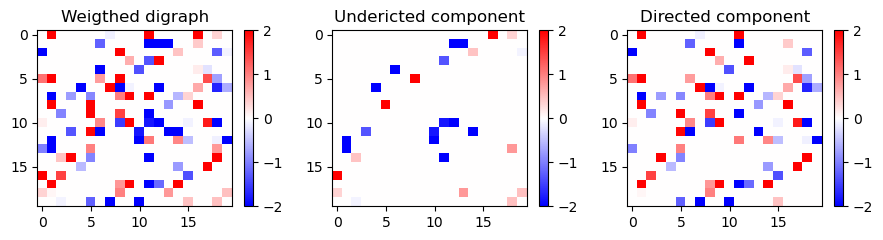

In [39]:
# Define the masks for the reciprocal and the directed components
mask = dirnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wnet_und = wdirnet * mask_und
wnet_dir = wdirnet * mask_dir

# Print some feedback ...
print( f"Are the networks directed?  wdirnet: {galib.is_directed(dirnet)}  \
undirected component: {galib.is_directed(wnet_und)}  directed component: {galib.is_directed(wnet_dir)}" )
print( f"Are the weights symmetric?  wdirnet: {galib.is_symmetric(dirnet)}  \
undirected component: {galib.is_symmetric(wnet_und)}  directed component: {galib.is_symmetric(wnet_dir)}" )


# Visualize the weighted adjacency matrix and the two components separately
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Weigthed digraph' )
plt.imshow(wdirnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Undericted component' )
plt.imshow(wnet_und, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,3)
plt.title( 'Directed component' )
plt.imshow(wnet_dir, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As we can see clearer now, the reciprocal links received symmetric weights, while directed links are obviously asymmetric.

## 2. Generating weighted random graphs from scratch

The basic random graph model comes in two forms: $G(N,p)$ is the model by Paul Erdös and Alfréd Rényi that evaluates the presence of every possible link with probability _p_, and the $G(N,L)$ model that seeds *L* links in an initially empy graph of *N* nodes. In *pyGAlib*, these two are generated calling functions `galib.models.ErdosRenyiGraph()` and `galib.models.RandomGraph()` respectively.

As shown in the previous section, the function `SeedRandomWeights()` can add random weights to any existing graph. Therefore, generating random weighted graphs can easily be achieved in two lines, as for example:
```python
>>> net = ErdosRenyiGraph(100, 0.05)
>>> wnet = SeedRandomWeights(net, numpy.random.uniform, low=0, high=1)
```

While this two-step process offers some flexibility (as will be shown in Section 2.1), for some common circumstances however, a one-call option is often more convenient. Thus *pyGAlib* includes two extra functions, `galib.models.WeightedERGraph()` and `WeightedRandomGraph()`, to generate random weighted (di)graphs in a single call (see Section 2.2).

### 2.1. – Flexible generation of surrogates

The function `SeedRandomWeights(net,...)` has optional parameter `copy` which controls the form of the output:

* if `copy = True` (default), the function returns a new adjacency matrix, keeping the original input matrix `net` unaltereded;
* if `copy = False` the input matrix `net` is overwritten in place (and the function returns None).

This allows for various flexible forms to generate ensembles of surrogate weighted matrices.

#### Case 1: efficiently iteration over realizations of one graph, with different random weights seeded every time.

The following cell generates one (random) graph and use the `copy = False` option to seed random weights over various realizations to compute some values. The process only uses the memory for one matrix at a time.


### 2.2 - Quick generation of random weighted (di)graphs

While the methods above can serve different purposes, the most common scenario is the one described in **Option-3**, where a set of independent random graphs are generated with the only common parameters beind their size *N* and link probability *p* (or number of links *L*). To simplify tthis, *pyGAlib* includes two functions for this case. The functions are "syntactic sugar" for the last case shown and work the same way:

* WeightedERGraph() :
* WeightedRandomGraph() :

blah…

In [44]:
# Explore the parameters of the weighted random graph generators
galib.WeightedERGraph?
#galib.WeightedRandomGraph?

Signature:
galib.WeightedERGraph(
    N,
    p,
    w_distr,
    directed=False,
    selfloops=False,
    sym_w=None,
    **arg_w_distr,
)
Docstring:
Generates a random graph of N nodes and link probability p, with link
weights assigned from a given random distribution.

Syntactic sugar for calling functions ErdosRenyiGraph() and SeedRandomWeights()
to generate a random graph with random weights in one command.

Parameters
----------
N : integer
    The size of the network (number of nodes).
p : float
    Probability of a link between each pair of nodes. Value between 0 and 1.
w_distr : function
    The distribution function for drawing weight samples, it must have a
    `size` argument for the number of generated samples. For example,
    random number generators from `numpy.random` or `scipy.random`.
directed : bool, optional, default: False
    True if a directed graph is desired. False, for an undirected graph.
selfloops : bool, optional, default: False
    True if self-loops are a

CONTINUE HERE !!

- Show a couple of examples with different parameters.
- Show the validation over ensemblres, that distributions conserve, etc.

## 3) Surrogate weighted graphs

Write me here ...